# Aufgabenstellung
0. Berechnen Sie während der Vorbereitung auf den Versuch analytisch die Fourier-Transformierten
einer Einzelspalt- und einer Doppelspaltfunktion und vergleichen Sie diese mit den für diese Objekte
bekannten Fraunhofer-Beugungsmustern. Ermitteln Sie mittels FFT (Fast-Fourier-Transform) die
Fourier-Transformierten der Funktionen $F(k) = \text{sinc}(2 \pi k) = \text{sin}(2 \pi k)/(2 \pi k)$ sowie $F(k)^2$. Diskutieren Sie
das Ergebnis unter Berücksichtigung des Faltungstheorems.

1. Messen Sie mit einer CCD-Zeilenkamera das Beugungsbild eines Einzelspalts im Grenzfall der
Fraunhoferbeugung.
Bestimmen Sie die Spaltbreite:
(a) aus der Lage der Minima verschiedener Ordnungen
(b) mittels FFT.

2. Messen Sie mit einer CCD-Zeilenkamera das Beugungsbild eines Doppelspalts im Grenzfall der
Fraunhoferbeugung.
Bestimmen Sie:
(a) den Spaltabstand aus der Lage der Minima verschiedener Ordnungen,
(b) Spaltbreite und Spaltabstand mit einem Fit des bekannten Fraunhofer-
Beugungsbilds an die Daten,
(c) Spaltbreite und Spaltabstand aus der FFT der Intensitätsverteilung.

3. Bestimmen Sie die Talbot-Länge eines Beugungsgitters. Messen Sie dazu mit einer CCD-
Zeilenkamera das Beugungsbild des Beugungsgitters für mehrere Abstände zwischen Kamera und
Gitter. Berechnen Sie die Fouriertransformierte und bestimmen Sie die Intensität des Peaks erster
Ordnung als Funktion des Abstands. Ermitteln Sie aus den Intensitätsoszillationen die Talbot-Länge.
Vergleichen Sie den experimentellen und den theoretischen Wert.

# Aufgabe 0
## Theoretische Grundlagen {#theo-grund}
Für unseren Versuch ist eine Theoretische Grundlage notwendig, die versucht wir in diesem Kapitell zu erlangen.

In diesem Fall ist der Abstand zwischen
Spalt/Doppelspalt und Kamera so groß, dass in guter Näherung ebene Wellen auf die Kamera treffen

Im Fraunhofer-Grenzfall welcher den Tall beschreibt wo der Abstand zwischen Spalt und Kamera so groß ist, dass die Welle in guter näherung als eben betrachtet werden, ist das Beugungsmuster $I(k)$ proportional zum Betrag der Fourier-Transformierten, der Öffnungsfunktion $f(x)$. Diese sind für einen (@eq-einen-spalt) und für zwei Spalten (@eq-zwei-spalten) folgendermaßen definert.
$$f_1(x) = \text{rect}\left(\frac{x}{a}\right)$${#eq-einen-spalt}
$$f_2(x) = \text{rect}\left(\frac{x+d/2}{a}\right) + \text{rect}\left(\frac{x-d/2}{a}\right)$${#eq-zwei-spalten}
Dabei sind für die Öffnungsfunktionen, die Fourier-Transformierten, die folgenden
$$F_1(k) = a ~ \text{sinc}(ka)$${#eq-fft1}
$$F_2(k) = 2a ~ \text{sinc}(ka) ~ \text{cos}(kd/2)$${#eq-fft2}
Nach der Beziehung $I(k) = |F(k)|²$, erhalten wir folgendes Fauenhofer-Beugungsmuster, welches das Intensitätsprofil ist.
$$I_2(k) \propto \text{sinc}²(ka)~\text{cos}²(kd/2)$$

## Vergleich der Einzelspalt- Doppelspaltfunktion mit den bekannten Fraunhoferbeugungsmustern

In [Abbildung #fig-fraunhofer-beugungsmuster] sind die analytischen Fraunhofer-Beugungsmuster zu sehen, für den Einzel- und Doppelspalt.
Dabei sind die geplotteten Funktionen, die Hergeleiteten Fouriertransforamtionen (@eq-fft1) (@eq-fft2), aus dem Kapitel @theo-grund .

Das analytische Fraunhofer-Beugungsmuster des Einzelspalts (blau) entspricht wie sichtbar der Funktion $I(k)=sinc^2(ak)$.

Beim Doppelspalt (orange) überlagern sich zwei Einzelspalte, was zu einer Modulation mit $cos^⁡2(kd/2)$ führt.

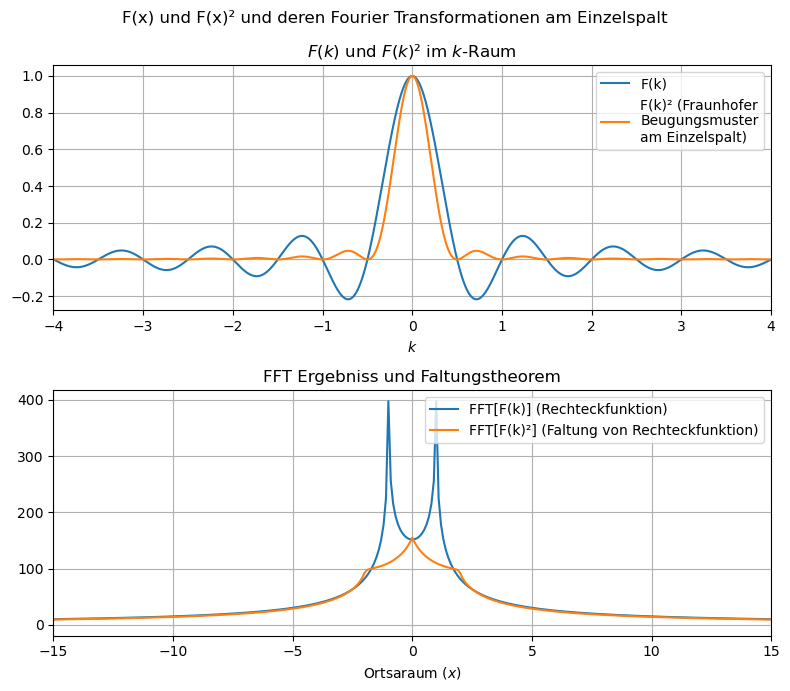

In [4]:
# | label: fig-vergleich
# | fig-cap:
# |     - Die Fourier-Transformierten Formeln, der Einzel-, Doppelspaltfunktion
# |     - Ergebnis der FFT von $F(k)$ und $F(k)²$

import numpy as np
from scipy.fft import fft, fftfreq, fftshift, ifft
import matplotlib.pyplot as plt

# Number of sample points

N = 10000

# sample spacing

T = 1 / 1000

def F(k): #Fraunhofer-Beugungsmuster eines Einzelspalts
    return np.sin(2 * np.pi * k)/(2 * np.pi * k)

x = np.linspace(0.1, N*T, N, endpoint=False)
k = np.linspace(-5, 5, N)
y = F(x)
y_squared = y**2 # Intensität, da I ~ |F|²

yf = fft(y) # Spaltfunktion im Ortraum (numerische FFT)
yf_squared = fft(y_squared) # FFT des Intensitätsmuster -> Faltung im Ortsraum
# damit ds Flatungstheorem erklähren

xf = fftfreq(N, T)

xf_shifted = fftshift(xf)
yf_shifted = fftshift(np.abs(yf))
yf_squared_shifted = fftshift(np.abs(yf_squared))

fig, axs = plt.subplots(2, 1, figsize=(8, 7))
fig.suptitle("F(x) und F(x)² und deren Fourier Transformationen am Einzelspalt")

axs[0].plot(k, F(k), label="F(k)")
axs[0].plot(k, F(k)**2, label="F(k)² (Fraunhofer\nBeugungsmuster\nam Einzelspalt)")
axs[0].set_xlim(-4, 4)
axs[0].grid()
axs[0].set_title("$F(k)$ und $F(k)²$ im $k$-Raum")
axs[0].set_xlabel("$k$")
axs[0].legend()


axs[1].plot(xf_shifted, yf_shifted, label="FFT[F(k)] (Rechteckfunktion)")
axs[1].plot(xf_shifted, yf_squared_shifted, label="FFT[F(k)²] (Faltung von Rechteckfunktion)")
axs[1].set_xlim(-15, 15)
axs[1].grid()
axs[1].set_title("FFT Ergebniss und Faltungstheorem")
axs[1].set_xlabel("Ortsaraum ($x$)")
axs[1].legend()

plt.tight_layout()
plt.show()

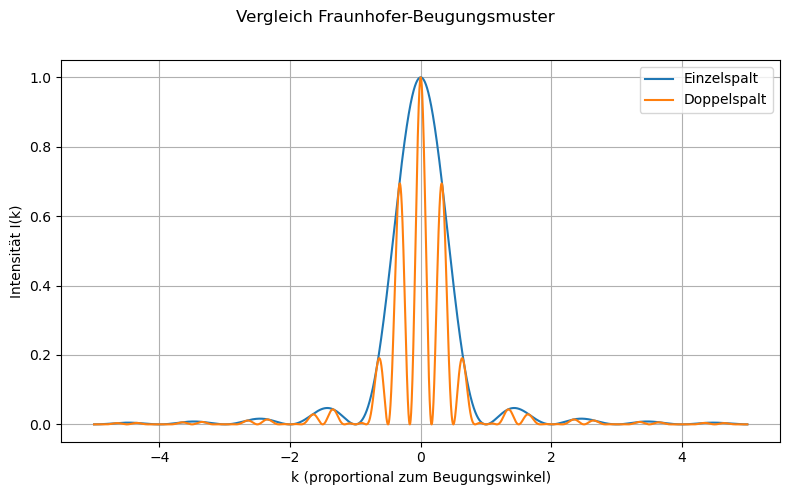

In [5]:
# | label: fig-fraunhofer-beugungsmuster
# | fig-cap: Vergleich Fraunhofer-Beugungsmuster mit Einzel- und Doppelspalt (analytisch)


# ============================================================
# 1️⃣ Grundparameter
# ============================================================
N = 10000          # Anzahl der Stützstellen
T = 1 / 1000       # Abtastintervall
k = np.linspace(-5, 5, N)  # "Frequenzraum" (k)

# ============================================================
# 2️⃣ Definition der Funktionen
# ============================================================

# Einzelspalt (Fraunhofer-Beugungsmuster)
def F_single(k, a=1.0):
    # sinc(x) = sin(pi*x)/(pi*x) in numpy -> np.sinc(x)
    return np.sinc(a * k)

# Doppelspalt (zwei Spalte mit Abstand d)
def F_double(k, a=1.0, d=3.0):
    return np.sinc(a * k) * np.cos(np.pi * d * k)

# ============================================================
# 3️⃣ Berechnung der Intensitätsverteilungen
# ============================================================
I_single = F_single(k)**2
I_double = F_double(k)**2

# ============================================================
# 4️⃣ FFT-Teil (numerischer Vergleich)
# ============================================================
# Aufgabe: Fourier-Transformierte von F(k) und F(k)^2

def F_func(k):
    return np.sin(2 * np.pi * k) / (2 * np.pi * k)

x = np.linspace(0.1, N*T, N, endpoint=False)
y = F_func(x)
y_squared = y**2

# FFT berechnen
Y_fft = fft(y)
Y_fft_squared = fft(y_squared)
xf = fftfreq(N, T)
xf_shifted = fftshift(xf)
Y_fft_shifted = fftshift(np.abs(Y_fft))
Y_fft_squared_shifted = fftshift(np.abs(Y_fft_squared))

# ============================================================
# 5️⃣ Plot-Ergebnisse
# ============================================================

fig, axs = plt.subplots(1, 1, figsize=(8, 5))
fig.suptitle("Vergleich Fraunhofer-Beugungsmuster")

# --- (1) Analytisch: Einzel- und Doppelspalt Fraunhofer-Muster ---
plt.plot(k, I_single, label="Einzelspalt")
plt.plot(k, I_double, label="Doppelspalt")
plt.xlabel("k (proportional zum Beugungswinkel)")
plt.ylabel("Intensität I(k)")
plt.legend()
plt.grid()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Diskussion unter berücksichtigung des Faltungstheorems
Das Faltungstheorem der Fourier-Transforamtion besagt:
$$FT[f(x) \ \otimes g(x) ] = FT \left[ \int_{- \infty}^{\infty}f(x')g(x-x')dx'\right] = FT[f(x)]FT[g(x)]=F(k)G(k)$$

Dies bedeutet, wenn im $k$-Raum multipliziert wird, wie es bei $F(k)²$ gemacht wurde, dann enspricht das im $x$-Raum eine Faltung der zugehörigen Funktionen.

Genau das kann in [Abbildung #fig-vergleich] beobachtet werden. So ergibt die FFT von $F(k)²$ eine verbreitete Form der ursprünglichen Funktion, welche die Faltung ist.

Somit stimmt, es mit dem Faltungstheorems überein.

# Aufgabe 1

Bei der ersten Aufgabe sollten wir das Beugungsbild vom Einzelspalt messen. Mithilfe des Beugungsbildes können wir dann die Spaltbreite bestimmen und mit den echten Werten vergleichen. Wir haben 4 Messungen gemacht mit verschiedenen Spaltbreiten: 0,2mm; 0,4mm; 0,8mm und 1,6mm. Wir nutzen zwei verfahren für die bestimmung der Spaltbreite, zum einen über den Abstand vom Hauptmaxima zum Minimum erster Ordnung und zum anderen mithilfe der Fouriertransformation.

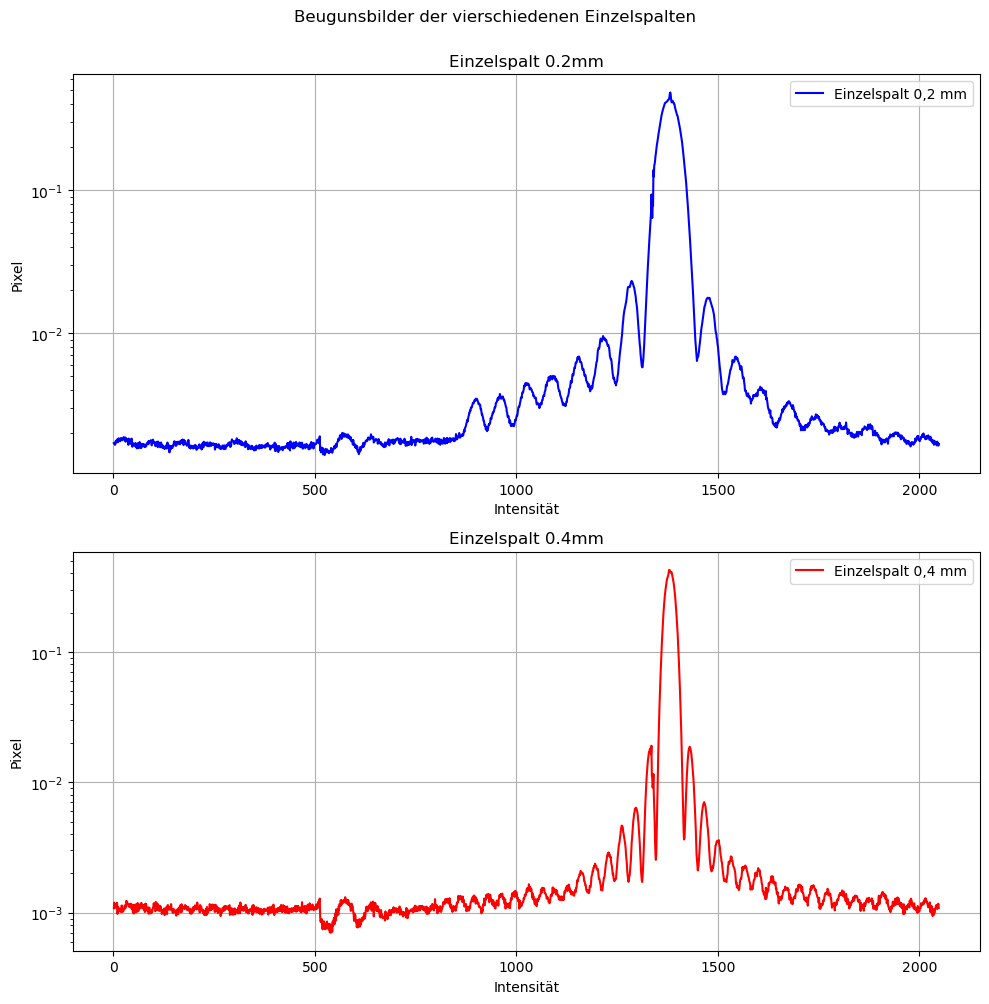

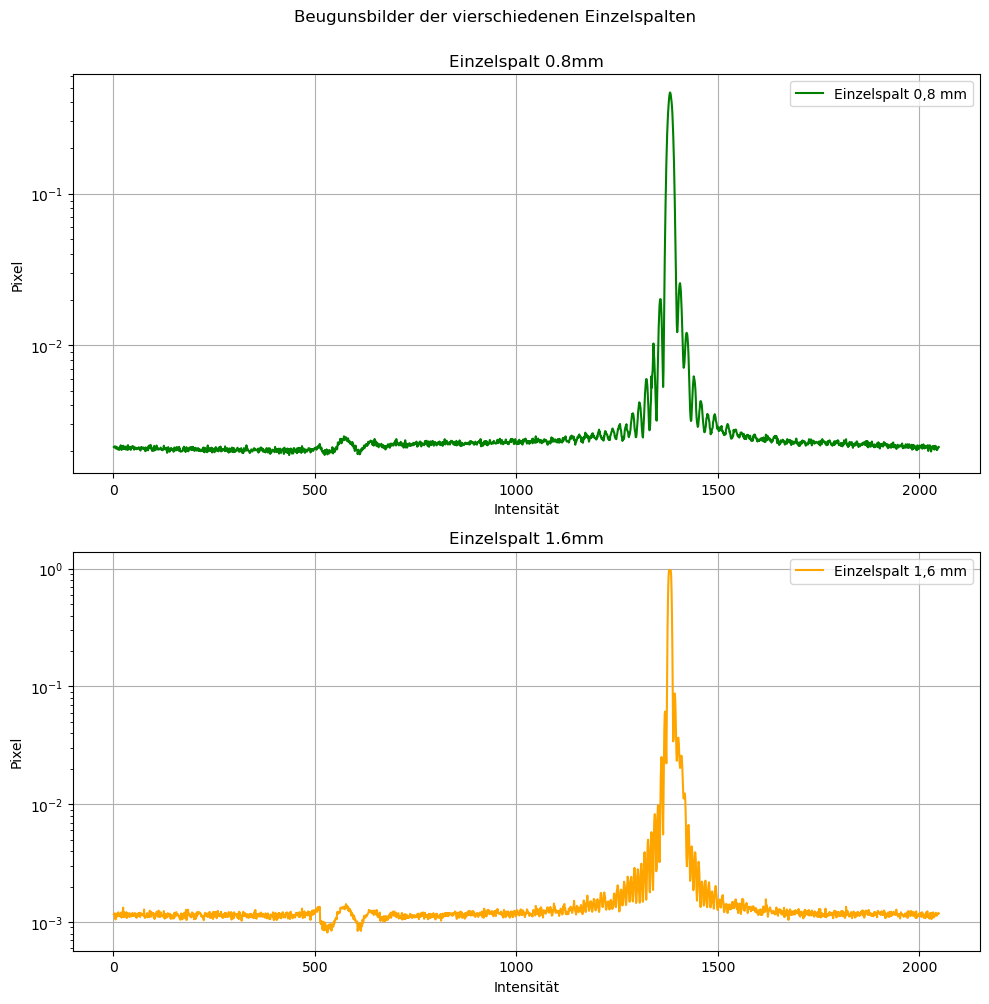

In [6]:
# | fig-cap: 
# |     - Gemessene Beugungsbilder aller Einzelspalten (0.2mm, 0.4mm, 0.8mm, 1.6mm) Part1
# |     - Gemessene Beugungsbilder aller Einzelspalten (0.2mm, 0.4mm, 0.8mm, 1.6mm) Part2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung02mm.csv")
dt = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung04mm.csv")
dn = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung08mm.csv")
dm = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung16mm.csv")


# Plot für a_x
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
fig.suptitle("Beugunsbilder der vierschiedenen Einzelspalten", y=1)

axs[0].plot(df['x'], df['y'], label="Einzelspalt 0,2 mm", color="blue")
axs[0].set_yscale("log")
axs[0].set_xlabel("Intensität")
axs[0].set_ylabel("Pixel")
axs[0].set_title("Einzelspalt 0.2mm")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(dt['x'], dt['y'], label="Einzelspalt 0,4 mm", color="red")
axs[1].set_yscale("log")
axs[1].set_xlabel("Intensität")
axs[1].set_ylabel("Pixel")
axs[1].set_title("Einzelspalt 0.4mm")
axs[1].grid(True)
axs[1].legend()

fig.tight_layout()
plt.show()

# Plot für a_x
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
fig.suptitle("Beugunsbilder der vierschiedenen Einzelspalten", y=1)

axs[0].plot(dn['x'], dn['y'], label="Einzelspalt 0,8 mm", color="green")
axs[0].set_yscale("log")
axs[0].set_xlabel("Intensität")
axs[0].set_ylabel("Pixel")
axs[0].set_title("Einzelspalt 0.8mm")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(dm['x'], dm['y'], label="Einzelspalt 1,6 mm", color="orange")
axs[1].set_yscale("log")
axs[1].set_xlabel("Intensität")
axs[1].set_ylabel("Pixel")
axs[1].set_title("Einzelspalt 1.6mm")
axs[1].grid(True)
axs[1].legend()

fig.tight_layout()
plt.show()

## Bestimmung der Spaltbreite mithilfe der Minima erster Ordnung

Da wir aus dem aufgenommenen Beugungsmuster auslesen können, wie viele pixel zwischen dem Maxima 0. Ordnung und den ersten Minima in beiden Richtungen liegen, können wir durch die Pixelgröße den Realabstand berechnen. Dadurch kann dann auf die Spaltbreite geschlossen werden. D. h. wir haben nehmen die pixelposition vom Maximum nullter Ordnung und die beiden ersten Minima und suche den Pixelabstand. Dann nehmen wir den Durchschnitt von den beiden und multiplizieren ihn mit der realen größe eines Pixels. Dieser war im Fall unseres Experiments 11 $\mu m$. Jetzt brauchen wir nur noch eine Formel um aus dem Abstand zum ersten Minimum die Spaltbreite zu berechnen. Dafür nutzen wir die Formel die beim Einzelspalt gilt:
$$sin(\alpha) \cdot b = n \cdot \lambda$$
Hierbei ist $n$ die Ordnungszahl des Minimums, $b$ die Spaltbreite, $\lambda$ die Wellenlänge und $\alpha$ der Winkel der n-ten Beugungsordnung. Bei unserem Aufbau sitzt die Kamera in der Brennweite von der Sammellinse und dabei gilt für kleine Winkel:
$$tan(\alpha) \approx sin(\alpha) \approx \frac{x}{f} \implies b \approx \frac{\lambda \cdot f}{x}$$
Hierbei ist x der Abstand auf der Kamera und f die Brennweite. Die Brennweite haben wir gegeben mit 308 mm und die Wellenlänge des genutzten Diodenlasers war 636 nm. Jetzt können wir die Spaltbreite mithilfe unseres Beugungsmusters berechnen. Da beim 1,6 mm Spalt das Minima erster Ordnung sehr schlecht abzulesen ist, haben wir nur die ersten 3 genutzt.


=== Auswertung für Einzelspalt-Daten 1 ===
-------------------------------------------------
Pixelposition Hauptmaximum         : 1380.0 px
Pixelposition 1. Minimum links     : 1312.0 px
Pixelposition 1. Minimum rechts    : 1450.0 px
Delta_px links                     : 68.0 px
Delta_px rechts                    : 70.0 px
gemitteltes Delta_px               : 69.0 px
Abstand                            : 9.660e-04 m
-------------------------------------------------
Spaltbreite b (nur 1. Ordnung)     : 2.028e-04 m
                                   = 202.78 µm
-------------------------------------------------
Pixelabweichung:  0.199  pixel


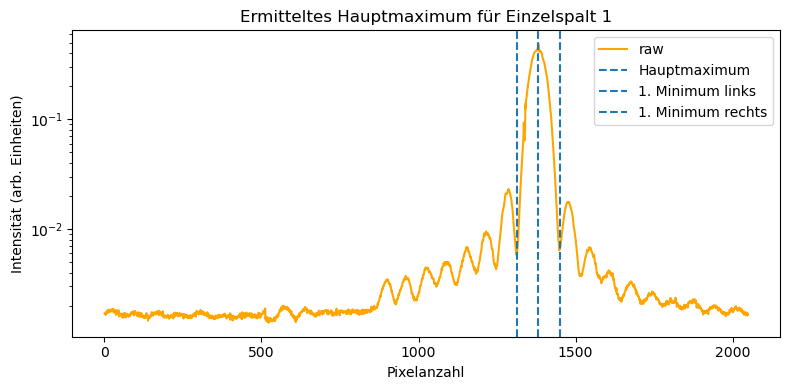


=== Auswertung für Einzelspalt-Daten 2 ===
-------------------------------------------------
Pixelposition Hauptmaximum         : 1381.0 px
Pixelposition 1. Minimum links     : 1346.0 px
Pixelposition 1. Minimum rechts    : 1417.0 px
Delta_px links                     : 35.0 px
Delta_px rechts                    : 36.0 px
gemitteltes Delta_px               : 35.5 px
Abstand                            : 4.970e-04 m
-------------------------------------------------
Spaltbreite b (nur 1. Ordnung)     : 3.941e-04 m
                                   = 394.14 µm
-------------------------------------------------
Pixelabweichung:  -0.419  pixel


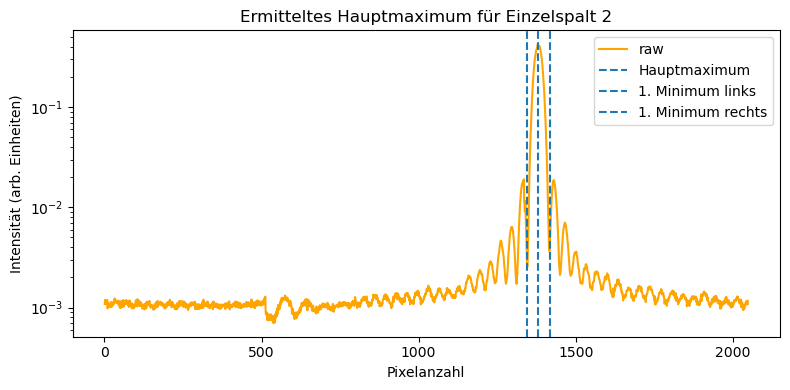


=== Auswertung für Einzelspalt-Daten 3 ===
-------------------------------------------------
Pixelposition Hauptmaximum         : 1382.0 px
Pixelposition 1. Minimum links     : 1363.0 px
Pixelposition 1. Minimum rechts    : 1400.0 px
Delta_px links                     : 19.0 px
Delta_px rechts                    : 18.0 px
gemitteltes Delta_px               : 18.5 px
Abstand                            : 2.590e-04 m
-------------------------------------------------
Spaltbreite b (nur 1. Ordnung)     : 7.563e-04 m
                                   = 756.32 µm
-------------------------------------------------
Pixelabweichung:  -3.120  pixel


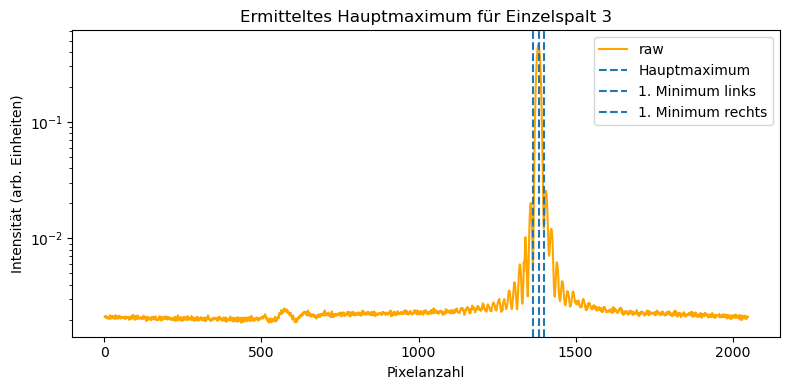

In [7]:
# | fig-cap:
# |     - Ermitteltes Hauptmaximum für Einzelspalt, sowie das ermittelte linke und rechte 1te Minimum vom Einzelspalt 0.2mm
# |     - Ermitteltes Hauptmaximum für Einzelspalt, sowie das ermittelte linke und rechte 1te Minimum vom Einzelspalt 0.4mm
# |     - Ermitteltes Hauptmaximum für Einzelspalt, sowie das ermittelte linke und rechte 1te Minimum vom Einzelspalt 0.8mm
# |     - Ermitteltes Hauptmaximum für Einzelspalt, sowie das ermittelte linke und rechte 1te Minimum vom Einzelspalt 1.6mm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ---------------------------------------------------
# 1) EXPERIMENTPARAMETER
# ---------------------------------------------------
lambda_ = 636e-9      # Wellenlänge in m (636 nm)
f = 0.308           # Brennweite der Linse in m -> HIER euren Wert eintragen!
pixel_size = 14e-6     # Pixelgröße in m (z.B. 7 µm)

einzelspalt_0_2 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung02mm.csv"
einzelspalt_0_4 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung04mm.csv"
einzelspalt_0_8 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung08mm.csv"
einzelspalt_1_6 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung16mm.csv"

spalte = [2, 4, 8]
# ---------------------------------------------------
# 2) Daten einlesen
# ---------------------------------------------------
df_1 = pd.read_csv(einzelspalt_0_2)
df_2 = pd.read_csv(einzelspalt_0_4)
df_3 = pd.read_csv(einzelspalt_0_8)
for i, df in enumerate([df_1, df_2, df_3], start=1):
    print(f"\n=== Auswertung für Einzelspalt-Daten {i} ===")
    x_pixels = df["x"].values          # Pixelindizes (1..N)
    I_raw = df["y"].values.astype(float)

    # ---------------------------------------------------
    # 3) Intensität leicht glätten
    # ---------------------------------------------------
    window = 7
    kernel = np.ones(window) / window
    I = np.convolve(I_raw, kernel, mode="same")

    # ---------------------------------------------------
    # 4) Hauptmaximum finden
    # ---------------------------------------------------
    peaks, _ = find_peaks(I)
    idx_max_main = peaks[np.argmax(I[peaks])]   # Index des höchsten Peaks
    x0_px = x_pixels[idx_max_main]              # Pixelposition des Hauptmaximums

    # ---------------------------------------------------
    # 5) Minima 1. Ordnung links und rechts vom Hauptmaximum
    #    -> Minima sind Peaks in -I
    # ---------------------------------------------------
    minima_idx, _ = find_peaks(-I)

    # Minima links/rechts vom Hauptmaximum
    minima_left = minima_idx[minima_idx < idx_max_main]
    minima_right = minima_idx[minima_idx > idx_max_main]

    # nächstgelegenes Minimum links/rechts = 1. Ordnung
    idx_min_left = minima_left[-1]    # größter Index < idx_max_main
    idx_min_right = minima_right[0]   # kleinster Index > idx_max_main

    x_left_px = x_pixels[idx_min_left]
    x_right_px = x_pixels[idx_min_right]

    # Pixelabstände vom Hauptmaximum
    delta_px_left = abs(x_left_px - x0_px)
    delta_px_right = abs(x_right_px - x0_px)

    # x1 als Mittelwert der beiden Seiten (sollten ideal gleich sein)
    delta_px = 0.5 * (delta_px_left + delta_px_right)
    x1_phys = delta_px * pixel_size   # Abstand 1. Minimum in Metern

    # ---------------------------------------------------
    # 6) Spaltbreite b aus Fraunhofer-Bedingung
    #    b * sin(alpha_1) = lambda,  sin(alpha_1) ≈ x1 / f
    #    -> b = lambda * f / x1
    # ---------------------------------------------------
    b = lambda_ * f / x1_phys
    pixelabweichung = (b*1e6 - spalte[i-1]*1e2)/(pixel_size*1e6)

    print("-------------------------------------------------")
    print(f"Pixelposition Hauptmaximum         : {x0_px:.1f} px")
    print(f"Pixelposition 1. Minimum links     : {x_left_px:.1f} px")
    print(f"Pixelposition 1. Minimum rechts    : {x_right_px:.1f} px")
    print(f"Delta_px links                     : {delta_px_left:.1f} px")
    print(f"Delta_px rechts                    : {delta_px_right:.1f} px")
    print(f"gemitteltes Delta_px               : {delta_px:.1f} px")
    print(f"Abstand                            : {x1_phys:.3e} m")
    print("-------------------------------------------------")
    print(f"Spaltbreite b (nur 1. Ordnung)     : {b:.3e} m")
    print(f"                                   = {b*1e6:.2f} µm")
    print("-------------------------------------------------")
    print(f"Pixelabweichung:  {pixelabweichung:.3f}  pixel")
    # ---------------------------------------------------
    # 7) Plot zur Kontrolle
    # ---------------------------------------------------
    # x-Achse um das Hauptmaximum zentrieren (in mm)
    x_rel_m = (x_pixels - x0_px) * pixel_size

    plt.figure(figsize=(8,4))
    plt.plot(x_pixels, I_raw, label="raw", color="orange")
    #plt.plot(x_rel_m * 1e3, I, label="smoothed", alpha=0.7)
    plt.title(f"Ermitteltes Hauptmaximum für Einzelspalt {i}")

    plt.axvline(x0_px, linestyle="--", label="Hauptmaximum")
    plt.axvline(x_left_px, linestyle="--", label="1. Minimum links")
    plt.axvline(x_right_px, linestyle="--", label="1. Minimum rechts")

    plt.yscale("log")
    plt.xlabel("Pixelanzahl")
    plt.ylabel("Intensität (arb. Einheiten)")
    plt.legend()
    plt.tight_layout()
    plt.show()


| Ursprüngliche Spaltbreite | Berechnete Spaltbreite | Prozentuale Abweichung | Abweichung in Pixeln |
| ------------------------------------------- | --------------------------------------- | ---------------------- |----------------------|
| 0,2 mm (200 µm)                             | 202.78µm                               | 1.390\%                | 0.199 |
| 0,4 mm (400 µm)                             | 394.14µm                               | 1.465\%                | -0.419 |
| 0,8 mm (800 µm)                             | 756.32µm                               | 5.460\%                | -3.120 |

: Tabelle mit den ursprünglischen, berechneten Spaltbreiten. Sowie die Prozentuale Abweichung, sowie die Abweichung in Pixeln


### Aufgabe 1b: Bestimmung der Spaltbreite mit Hilfe der Fouriertransformation

#### Ziel

In diesem Aufgabenteil soll die Spaltbreite $b$ nicht wie in 1a über die Position der Minima im Beugungsbild bestimmt werden, sondern über eine numerische Fouriertransformation der gemessenen Intensitätsverteilung. Aus dem Frequenzspektrum rekonstruieren wir die Ausdehnung des Spalts im Ortsraum.

#### Theoretischer Hintergrund

Ein idealer Einzelspalt der Breite $b$ hat im Spaltkoordinatenraum die Transmission

$$
A(x) =
\begin{cases}
1, & |x| \le \frac{b}{2} \\
0, & \text{sonst}
\end{cases}
$$

Die Fraunhoferbeugung am Einzelspalt liefert für die Feldamplitude in der Fernzone eine sinc Funktion. Die Intensität im Fernfeld (z.B. auf der CCD Kamera) hat die Form
$I(x) \propto \text{sinc}^2\!\left(\frac{\pi b x}{\lambda f}\right)$, wobei die Variablen genau wie in a) vergeben sind. Die Fouriertransformation der Intensität $I(x)$ besitzt eine besondere Eigenschaft, sie ist proportional zur Autokorrelationsfunktion des Spalts. Die Autokorrelation einer Rechteckfunktion ergibt eine Dreiecksform mit Basisbreite $2b$. Aus der Breite dieser Dreiecksform können wir also direkt auf $b$ schließen.
#### Vorgehensweise

1. **Einlesen und Zentrieren der Daten**  
   - Einlesen der Messdaten $I(x_\text{pixel})$ aus den CSV Dateien.  
   - Umrechnung von Pixelnummern in Kamerakoordinate  
     $x = (x_\text{pixel} - x_{0,\text{pixel}})\cdot \text{pixel\_size}$
     wobei $x_{0,\text{pixel}}$ die Position des Hauptmaximums ist.

2. **Übergang von Kamerakoordinate zu Raumfrequenz**  
   Im Linsen Fraunhoferaufbau gilt für kleine Winkel
   $\sin\alpha \approx \frac{x}{f}$ $\quad\Rightarrow\quad$ $\kappa = \frac{\sin\alpha}{\lambda} \approx \frac{x}{\lambda f}$
   Die Größe $\kappa$ wird als Raumfrequenz bezeichnet. Sie gibt an, wie schnell das Beugungsmuster im Raum hin und her wechselt (Anzahl der Helligkeitsschwingungen pro Längeneinheit). Wir definieren also eine gleichabständige Raumfrequenzachse
   $\kappa_i = \frac{x_i}{\lambda f}$
   und tragen die gemessene Intensität als Funktion von $\kappa_i$ auf.


3. **Numerische Fouriertransformation**  
   - Wir berechnen die diskrete Fouriertransformation der gemessenen Intensität $I(\kappa)$ mit `numpy.fft.fft`.  
   - Die transformierte Funktion $G(x') = \mathcal{F}\{I(\kappa)\}$ wird gegen eine neue Variable $x'$ aufgetragen, die wieder eine Ortskoordinate in der Spaltebene repräsentiert (Autokorrelation des Spalts).

4. **Bestimmung der Basisbreite der Dreiecksform**  
   - Wir bestimmen die Position des Maximums von $G(x')$.  
   - Anschliessend suchen wir auf der linken und rechten Seite die Stellen, an denen $G(x')$ unter einen kleinen Schwellwert (wir nutzen 5% des Maximums) fällt. Diese Punkte approximieren die Nullstellen der Dreiecksform.  
   - Die Differenz der beiden Positionen $\Delta x' \approx 2b$ entspricht näherungsweise der Basisbreite der Dreiecksform.

5. **Berechnung der Spaltbreite**  
   Aus der gemessenen Breite $\Delta x'$ ergibt sich die Spaltbreite zu
   $b \approx \frac{\Delta x'}{2}$
   Den Wert $b$ vergleichen wir dann mit unseren Spaltbreiten, die wir im Versuch genutzt haben.


Einzelspalt 0.2 mm
--------------------------------------------
Pixelposition Hauptmaximum : 1380.0 px
x'_links  (ca. -b)         : -225.5 µm
x'_rechts (ca. +b)         : 225.5 µm
Breite 2b (FFT)            : 450.9 µm
Spaltbreite b (FFT)        : 2.255e-04 m = 225.5 µm

Abweichung in Pixeln:  1.818  pixel


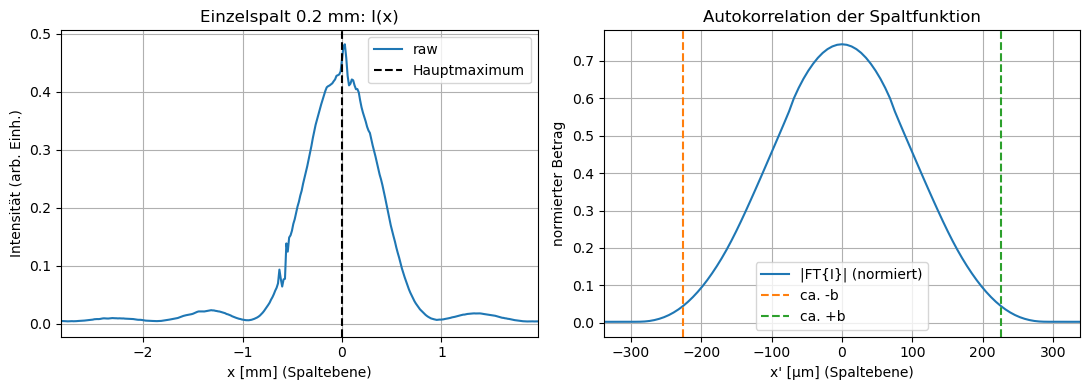

Einzelspalt 0.4 mm
--------------------------------------------
Pixelposition Hauptmaximum : 1381.0 px
x'_links  (ca. -b)         : -396.3 µm
x'_rechts (ca. +b)         : 396.3 µm
Breite 2b (FFT)            : 792.5 µm
Spaltbreite b (FFT)        : 3.963e-04 m = 396.3 µm

Abweichung in Pixeln:  -0.267  pixel


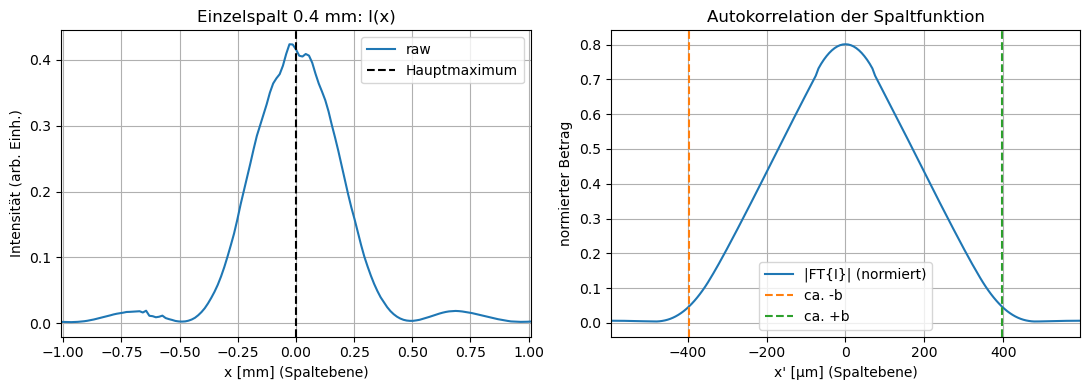

Einzelspalt 0.8 mm
--------------------------------------------
Pixelposition Hauptmaximum : 1382.0 px
x'_links  (ca. -b)         : -737.9 µm
x'_rechts (ca. +b)         : 737.9 µm
Breite 2b (FFT)            : 1475.7 µm
Spaltbreite b (FFT)        : 7.379e-04 m = 737.9 µm

Abweichung in Pixeln:  -4.439  pixel


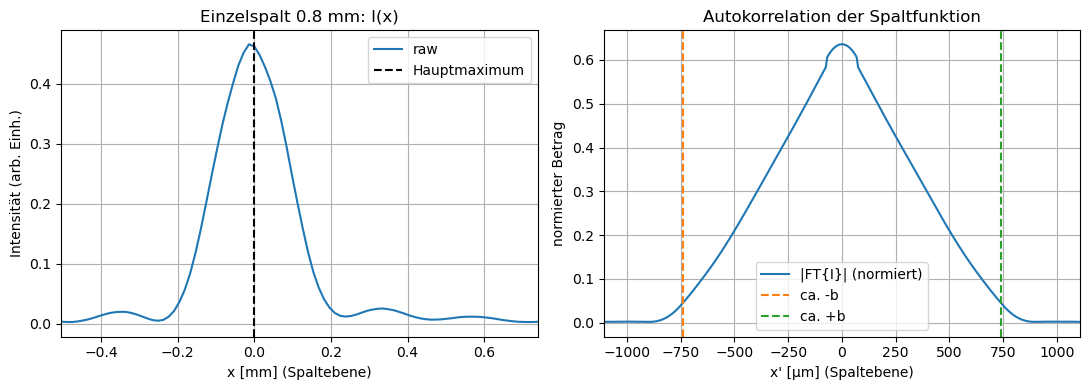

In [8]:
# | fig-cap:
# |     - FFT vom Einzelspalt 0.2mm und Autokorrelation
# |     - FFT vom Einzelspalt 0.4mm und Autokorrelation
# |     - FFT vom Einzelspalt 0.8mm und Autokorrelation
# |     - FFT vom Einzelspalt 1.6mm und Autokorrelation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 1) Parameter
lambda_ = 636e-9      # Wellenlänge in m
f       = 0.308       # Brennweite der Linse in m
pixel_size = 14e-6     # Pixelgröße in m

files = [
    ("0.2 mm", "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung02mm.csv"),
    ("0.4 mm", "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung04mm.csv"),
    ("0.8 mm", "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung08mm.csv"),
]

def slit_width_from_fft(csv_path, label, plot=True):
    # 2) Daten einlesen
    df = pd.read_csv(csv_path)
    x_pixels = df["x"].values
    I_raw    = df["y"].values.astype(float)

    # leichte Glättung
    window = 7
    kernel = np.ones(window) / window
    I = np.convolve(I_raw, kernel, mode="same")

    # 3) Hauptmaximum finden
    peaks, _ = find_peaks(I)
    idx_max_main = peaks[np.argmax(I[peaks])]
    x0_px = x_pixels[idx_max_main]

    # Pixel -> Kamerakoordinate (relativ zum Hauptmaximum)
    x_rel_px = x_pixels - x0_px
    x_cam = x_rel_px * pixel_size        # in m, x=0 am Hauptmaximum

    # 4) x -> kappa = x / (lambda * f)
    kappa = x_cam / (lambda_ * f)
    d_kappa = np.mean(np.diff(kappa))

    # 5) FFT in kappa
    I_k = I
    G = np.fft.fft(I_k) * d_kappa
    x_prime = np.fft.fftfreq(len(I_k), d=d_kappa)
    G_shift = np.fft.fftshift(G)
    x_prime_shift = np.fft.fftshift(x_prime)

    mag = np.abs(G_shift)
    mag /= mag.max()

    # glätten im x'-Raum
    win_ft = 21
    kernel_ft = np.ones(win_ft) / win_ft
    mag_smooth = np.convolve(mag, kernel_ft, mode="same")

    # 6) Dreiecksbreite bestimmen
    center = np.argmax(mag_smooth)
    idx = np.arange(len(mag_smooth))
    thr = 0.05   # 5 % Schwelle

    right_idx = np.where((idx > center) & (mag_smooth < thr))[0][0]
    left_idx  = np.where((idx < center) & (mag_smooth < thr))[0][-1]

    x_left  = x_prime_shift[left_idx]
    x_right = x_prime_shift[right_idx]

    width_support = x_right - x_left    # ca. 2b
    b_est = width_support / 2.0

    spalt = float(label[0:3])
    pixelabweichung = (b_est*1e6 - spalt*1e3)/(pixel_size*1e6)


    print("============================================")
    print(f"Einzelspalt {label}")
    print("--------------------------------------------")
    print(f"Pixelposition Hauptmaximum : {x0_px:.1f} px")
    print(f"x'_links  (ca. -b)         : {x_left*1e6:.1f} µm")
    print(f"x'_rechts (ca. +b)         : {x_right*1e6:.1f} µm")
    print(f"Breite 2b (FFT)            : {width_support*1e6:.1f} µm")
    print(f"Spaltbreite b (FFT)        : {b_est:.3e} m = {b_est*1e6:.1f} µm")
    print("============================================\n")
    print(f"Abweichung in Pixeln:  {pixelabweichung:.3f}  pixel")
    # 7) Plots mit Zoom
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))

        # (a) Beugungsbild in Kamerabene
        axes[0].plot(x_cam * 1e3, I_raw, label="raw")
        #axes[0].plot(x_cam * 1e3, I,     label="smoothed", alpha=0.7)
        axes[0].axvline(0.0, linestyle="--", color="k", label="Hauptmaximum")
        axes[0].set_xlabel("x [mm] (Spaltebene)")
        axes[0].set_ylabel("Intensität (arb. Einh.)")
        axes[0].set_title(f"Einzelspalt {label}: I(x)")
        axes[0].legend()
        axes[0].grid(True)

        # Zoom im Kameraplot: nur Bereich, wo I signifikant ist
        mask_cam = I > 0.02 * I.max()   # alles ueber 2 % vom Maximum
        if np.any(mask_cam):
            x_min_cam = x_cam[mask_cam].min()
            x_max_cam = x_cam[mask_cam].max()
            margin = 1.2
            axes[0].set_xlim(x_min_cam*1e3*margin, x_max_cam*1e3*margin)

        # (b) Betrag der Fouriertransformierten |FT{I}|
        axes[1].plot(x_prime_shift * 1e6, mag_smooth, label="|FT{I}| (normiert)")
        axes[1].axvline(x_left * 1e6,  linestyle="--", color="C1", label="ca. -b")
        axes[1].axvline(x_right * 1e6, linestyle="--", color="C2", label="ca. +b")
        axes[1].set_xlabel("x' [µm] (Spaltebene)")
        axes[1].set_ylabel("normierter Betrag")
        axes[1].set_title("Autokorrelation der Spaltfunktion")
        axes[1].legend()
        axes[1].grid(True)

        # Zoom im FFT Plot: nur Bereich um -b bis +b mit etwas Rand
        margin_fft = 1.5
        x_min_fft = x_left * margin_fft
        x_max_fft = x_right * margin_fft
        axes[1].set_xlim(x_min_fft*1e6, x_max_fft*1e6)

        plt.tight_layout()
        plt.show()

    return b_est, pixelabweichung


# alle Dateien auswerten
b_fft_results = []
for label, path in files:
    b_est, pixelabweichung = slit_width_from_fft(path, label, plot=True)
    b_fft_results.append((label, b_est, pixelabweichung))

#print("Zusammenfassung b (FFT Methode):")
#for label, b_est, pixelabweichung in b_fft_results:
    # print(f"{label}: b_FFT = {b_est*1e6:.1f} µm")
    # print(f"{pixelabweichung} Pixel Abweichung")
    # print("--------------------------------------------")


| Ursprüngliche Spaltbreite  | Berechnete Spaltbreite | Prozentuale Abweichung | Abweichung in Pixeln |
| ------------------------------------------- | --------------------------------------- | ---------------------- | -------------------- |
| 0.2 mm (200 µm)                             | 225.5 µm                                | 10.28\%                | 1.818                |
| 0.4 mm (400 µm)                             | 396.3 µm                                | 0.925\%                | 0.267                |
| 0.8 mm (800 µm)                             | 737.9 µm                                | 7.763\%                | 4.439                |

: Tabelle mit der ursprünglichen, berechneten Spaltbreite. Sowie die prozentuale Abweichung und die Abweichung in Pixeln


# Aufgabe 2
Aufgabe 2 ist sehr analog zu Aufgabe 1. Nur dass bei dieser Aufgabe, der Laserstrahl durch einen Doppelspalt anstatt durch einen Einzelspalt ging. Am Experimentieraufbau wurde außer dem Spalt nix geändert. Auch das Messverfahren bleib dass selbe. Nur die Streueungseffekte, die in der Fehlerbetrachtung genauer beschrieben wurden, sind bei dieser Aufgabe heftiger aufgetreten.

In [9]:
# Imports und Experimentparameter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.fft import fft, fftshift, fftfreq
import warnings
warnings.filterwarnings('ignore')

# experimentelle Konstanten (wie in Aufgabe 1)
lambda_ = 636e-9       # Laserwellenlänge in m
f = 0.308              # Brennweite in m
pixel_size = 14e-6     # Pixelgröße in m

# Dateipfade (Aufnahme 1 mm und 2 mm Beispielnamen aus Repo)
fn1 = 'O17 Messdaten/Aufgabe 2/DoppelspatlBeugung01mm.csv'  # Achtung: Dateiname in Repo enthält ein 'l'
fn2 = 'O17 Messdaten/Aufgabe 2/DoppelspaltBeugung02mm.csv'

# Prüfe Verfügbarkeit
for p in [fn1, fn2]:
    try:
        _ = pd.read_csv(p)
    except Exception as e:
        print(f'Warnung: Datei {p} konnte nicht gelesen werden: {e}')


## (a) Spaltabstand g aus Lage der Minima verschiedener Ordnungen
In Aufgabe 2a) soll der Spaltabstand mittels Linearer Regression ermittelt werden. Dabei müssen wir die symmetrische Minima links/rechts vom Hauptmaximum suchen sowie berechnen und $2x_n$ für mehrere Ordnungen $n$ führen eine lineare Regression gegen $(n+0.5)$ machen.  
Aus der Beziehung $2 x_n = \frac{2 f \lambda}{g} (n + 0.5)$ folgt für die Steigung m: $m = \frac{2 f \lambda}{g}$ und damit $g = \frac{2 f \lambda}{m}$.

Dabei kommen wir auf einen Spaltabstand von $g=0.3401$ mm.


Berechneter Spaltabstand g = 0.3401 mm


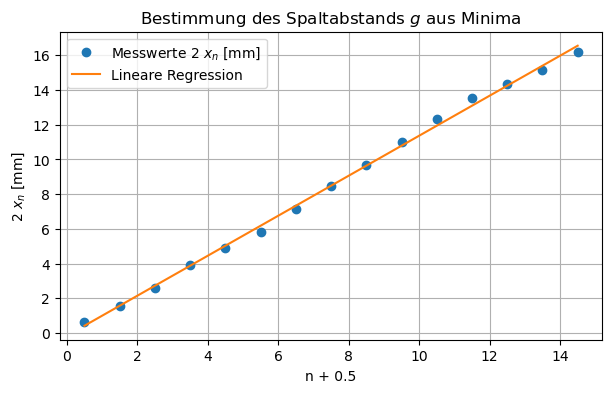

In [10]:
# | fig-cap: Bestimmung der Spaltabstands mittels Regression, wobei der zweifache Abstand der Minima geplottet wurde. Dabei werden die Minima und Maxima benötigt, welche mit der find_peak Funktion von dem Python Modul SciPy gefunden werden.
# --- (a) Minima finden und lineare Regression ---

# Wähle Messdatei (primär die 02mm Messung, falls vorhanden)
data_file = fn1

# Einlesen
df = pd.read_csv(data_file)
x_px = df['x'].values
I_raw = df['y'].values.astype(float)

# leichte Glättung
kernel = np.ones(7) / 7.0
I = np.convolve(I_raw, kernel, mode='same')

# Hauptmaximum bestimmen
peaks, _ = find_peaks(I)
idx_max = peaks[np.argmax(I[peaks])]
x0_px = x_px[idx_max]

# Minima als Peaks in -I
minima_idx, _ = find_peaks(-I, distance=5)
minima_left = minima_idx[minima_idx < idx_max]
minima_right = minima_idx[minima_idx > idx_max]

# Wähle paarweise Minima symmetrisch
Npairs = min(len(minima_left), len(minima_right))
pairs = []
two_x = []
for n in range(Npairs):
    il = minima_left[::-1][n]
    ir = minima_right[n]
    xl = (il - x0_px) * pixel_size
    xr = (ir - x0_px) * pixel_size
    pairs.append((il, ir))
    two_x.append(abs(xr - xl))

two_x = np.array(two_x)
n_vals = np.arange(len(two_x))
independent = n_vals + 0.5

# lineare Regression
m, c = np.polyfit(independent, two_x, 1)
g_from_minima = 2 * f * lambda_ / m

#print('--- Ergebnis (a): Spaltabstand aus Minima (Regression) ---')
#print(f'Verwenden: {data_file}')
#for i, (il, ir) in enumerate(pairs):
#    print(f'Ordnung n={i}: Minima px (links,right)=({il},{ir}), 2x_n = {two_x[i]*1e3:.3f} mm')
#print('\nRegression: 2 x_n = m*(n+0.5) + c')
#print(f'm = {m:.3e} m, c = {c:.3e} m')
print(f'Berechneter Spaltabstand g = {g_from_minima*1e3:.4f} mm')

# Plot
plt.figure(figsize=(7,4))
plt.plot(independent, two_x*1e3, 'o', label='Messwerte 2 $x_n$ [mm]')
x_lin = np.linspace(independent.min(), independent.max(), 50)
plt.plot(x_lin, (m*x_lin + c)*1e3, '-', label='Lineare Regression')
plt.xlabel('n + 0.5')
plt.ylabel('2 $x_n$ [mm]')
plt.title('Bestimmung des Spaltabstands $g$ aus Minima')
plt.legend()
plt.grid(True)
plt.show()


## (c) FFT-Methode: Spaltabstand g und Spaltbreite b aus der FFT der Intensitätsverteilung

Wir berechnen die Fourier-Transformation (FFT) der gemessenen Intensitätsverteilung. Die FFT wandelt das Signal in den Frequenzraum, wobei die Position der Hauptpeaks direkt mit dem Spaltabstand $g$ zusammenhängt, dabei liegen die Peaks bei $\pm g/2$. Die Breite des zentralen Maximums (Autokorrelations-Basisbreite) in der FFT ist umgekehrt proportional zur Spaltbreite $b$. Je schmaler der Spalt, desto breiter ist das zentrale Maximum in der Fourier-Transformierten. Deshalb kann man aus der Basisbreite eine Schätzung für $b$ erhalten.

So kommen wir für den Spaltabstand $g = 0.3006$ mm und als Schätzung aus der Autokorrelation auf einen Spaltbreit von $b = 143.47$ µm.

Schätzung g (FFT) = 0.3006 mm
Schätzung b (FFT, aus Autokorrelation) = 143.47 µm


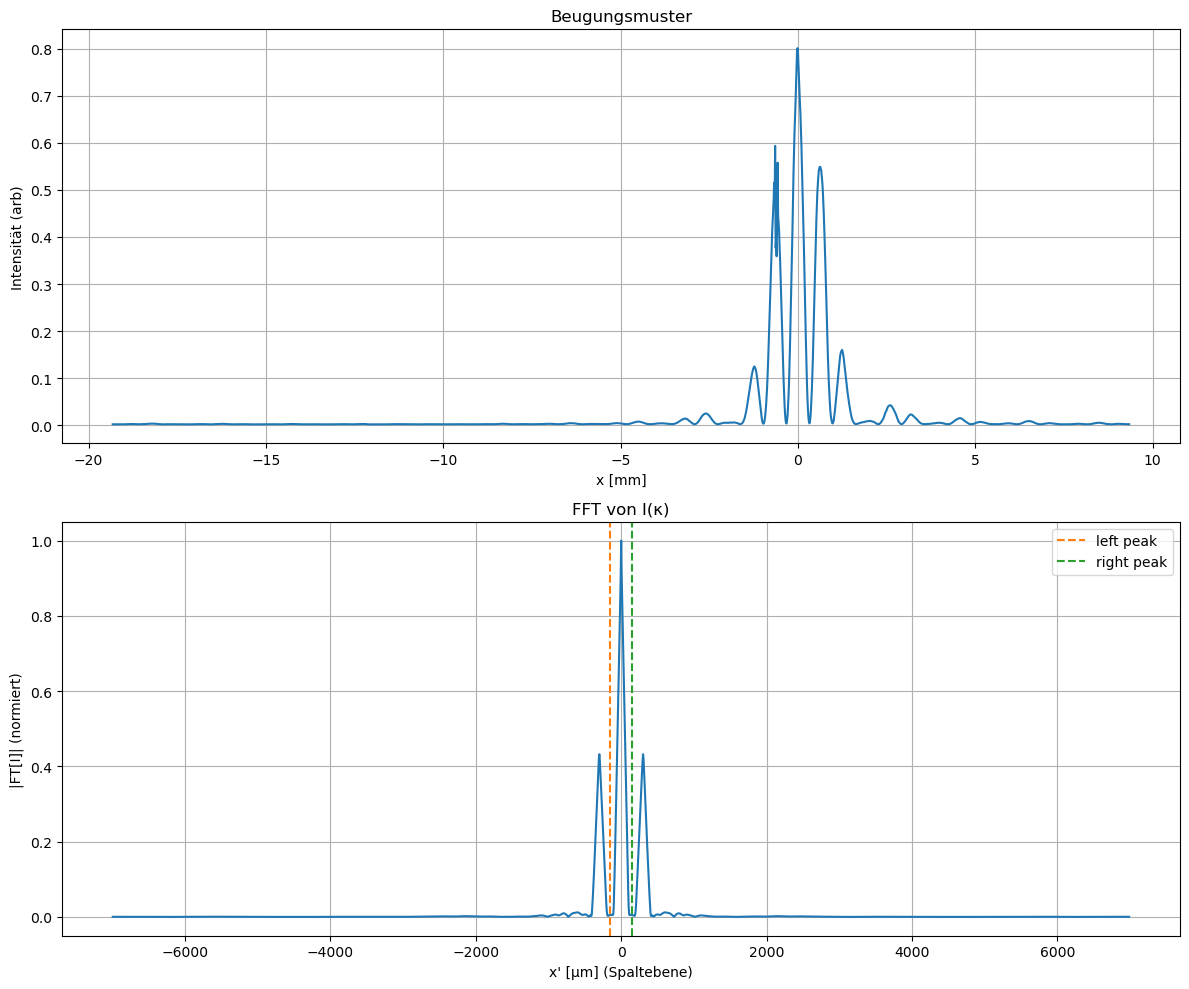

In [11]:
# | fig-cap: FFT-Analyse Links wo die breite des Hauptmaximas ermittelt wurde und Rechts das Beugungsbild

# --- (c) FFT-Analyse ---

df = pd.read_csv(data_file)
x_px = df['x'].values
I_raw = df['y'].values.astype(float)

# Center auf Hauptmaximum
I_smooth = np.convolve(I_raw, np.ones(9)/9, mode='same')
peaks, _ = find_peaks(I_smooth)
idx_max = peaks[np.argmax(I_smooth[peaks])]
x0_px = x_px[idx_max]

x_cam = (x_px - x0_px) * pixel_size  # m
kappa = x_cam / (lambda_ * f)  # Raumfrequenz sin(alpha)/lambda
d_kappa = np.mean(np.diff(kappa))

I_k = I_smooth
G = fft(I_k) * d_kappa
G_shift = fftshift(G)
x_prime = fftshift(fftfreq(len(I_k), d=d_kappa))  # x' in meters (Spaltebene)
mag = np.abs(G_shift)

# Finde Peaks in |FT{I}| (Peaks bei +/- g/2 oder Abständen ~g anzeigen)
peak_idx, _ = find_peaks(mag, height=0.1*mag.max())
if len(peak_idx) >= 2:
    center = len(mag)//2
    lefts = peak_idx[peak_idx < center]
    rights = peak_idx[peak_idx > center]
    if len(lefts) and len(rights):
        il = lefts[-1]
        ir = rights[0]
        x_left = x_prime[il]
        x_right = x_prime[ir]
        g_fft = abs(x_right - x_left)
    else:
        g_fft = np.nan
else:
    g_fft = np.nan

# Abschätzung b aus Autokorrelations-Basisbreite
mag_smooth = np.convolve(mag/ mag.max(), np.ones(21)/21, mode='same')
thr = 0.05
center_idx = np.argmax(mag_smooth)
left_idx = np.where((np.arange(len(mag_smooth)) < center_idx) & (mag_smooth < thr))[0]
right_idx = np.where((np.arange(len(mag_smooth)) > center_idx) & (mag_smooth < thr))[0]
if left_idx.size and right_idx.size:
    left_i = left_idx[-1]
    right_i = right_idx[0]
    width_support = x_prime[right_i] - x_prime[left_i]  # ~ 2 b (m)
    b_fft = width_support / 2.0
else:
    b_fft = np.nan

#print('--- Ergebnis (c): FFT-Methode ---')
print(f'Schätzung g (FFT) = {g_fft*1e3 / 2:.4f} mm')
print(f'Schätzung b (FFT, aus Autokorrelation) = {b_fft*1e6:.2f} µm')

# Plot: I(x) und |FT{I}| (x' in µm)
fig, ax = plt.subplots(2,1, figsize=(12,10))
ax[0].plot(x_cam*1e3, I_raw, label='raw')
ax[0].set_xlabel('x [mm]')
ax[0].set_ylabel('Intensität (arb)')
ax[0].set_title('Beugungsmuster')
ax[0].grid(True)

ax[1].plot(x_prime*1e6, mag/ mag.max())
ax[1].set_xlabel("x' [µm] (Spaltebene)")
ax[1].set_ylabel('|FT[I]| (normiert)')
ax[1].set_title('FFT von I(κ)')
ax[1].grid(True)
if not np.isnan(g_fft):
    ax[1].axvline(x=(x_left*1e6/2), color='C1', linestyle='--', label='left peak')
    ax[1].axvline(x=(x_right*1e6/2), color='C2', linestyle='--', label='right peak')
    ax[1].legend()
plt.tight_layout()
plt.show()


## (b) Nichtlinearer Fit: Bestimmung von b und g durch Fit des Fraunhofer-Modells

In Teilaufgbae (b) soll das folgende Modell gefitteted werrden um auch den Spaltabstand und die Spaltbreite zu erhalten.

$$I(x) = A\cdot\mathrm{sinc}^2\!\left(\pi\sin\alpha\frac{b}{\lambda}\right)\cdot\cos^2\!\left(\pi\sin\alpha\frac{g}{\lambda}\right)+\mathrm{bg}$$

mit der kleinen Winkel‑Approximation $\sin\alpha\approx x/f$ die wir nutzen dürfen, da wir uns im Fernfeld bzw. Frauenhofer_Grenzfall befinden. Dabei sind A die Amplitude, bg der Hintergrund, b als Spaltbreite und g als Spaltabstand freie Fitparameter. Jedoch werden als Anfangswerte bei $b$ und $g$ die Ermittelten Werte von Teilaufgabe (a) und (c) genommen.

Damit gewinnt man verlässliche Schätzwerte für b und g, einschließlich eine Fehlerabschätzungen aus der Kovarianzmatrix.

So erhalten wir aus dem Fit eine Spaltbreite $b = 102.57 \pm 0.77$ µm sowie einen Spaltabstand $g=0.3008 \pm 0.0006$ mm

b = 102.57 µm (±0.77 µm)
g = 0.3008 mm (±0.0006 mm)


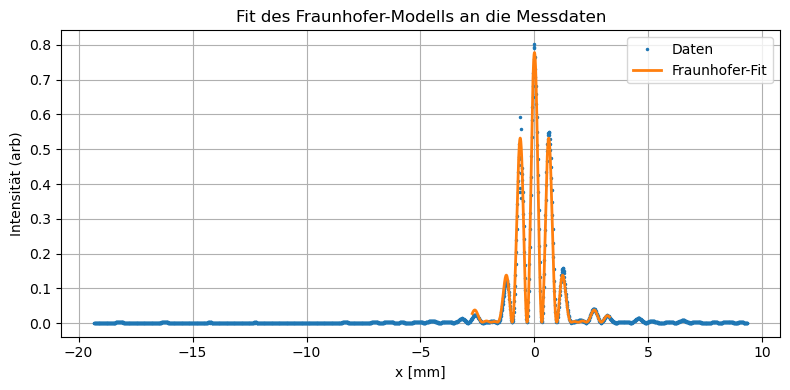

In [12]:
# | fig-cap: Nicht linearer Fit des Frauenhofermodells, wobei der Fit sehr gut die Daten bedeckt.

# --- (b) Fit des Fraunhofer-Modells ---

# Auswahl des Fitbereichs: dort, wo I > 2% des Maximums
mask = I_raw > 0.02 * I_raw.max()
if np.sum(mask) < 10:
    mask = np.ones_like(I_raw, dtype=bool)
x_fit = x_cam[mask]
y_fit = I_raw[mask]

def fraunhofer_model(x, A, bg, b, g):
    sinalpha = x / f
    env = np.sinc(sinalpha * b / lambda_)**2
    carrier = np.cos(np.pi * sinalpha * g / lambda_)**2
    return A * env * carrier + bg

# Startwerte
A0 = y_fit.max()
bg0 = np.median(y_fit[:10])
b0 = b_fft if (not np.isnan(b_fft)) else 5e-4
g0 = g_from_minima if (not np.isnan(g_from_minima)) else (g_fft if (not np.isnan(g_fft)) else 2e-3)

p0 = [A0, bg0, b0, g0]

bounds_lower = [0.0, 0.0, 1e-6, 1e-5]
bounds_upper = [np.inf, np.inf, 5e-2, 5e-2]
try:
    popt, pcov = curve_fit(fraunhofer_model, x_fit, y_fit, p0=p0, bounds=(bounds_lower, bounds_upper), maxfev=20000)
    A_fit, bg_fit, b_fit, g_fit = popt
    perr = np.sqrt(np.diag(pcov))
except Exception as e:
    print('Fit fehlgeschlagen:', e)
    A_fit, bg_fit, b_fit, g_fit = (np.nan,)*4
    perr = [np.nan]*4

#print('--- Ergebnis (b): Nichtlinearer Fit ---')
#print(f'A = {A_fit:.3e} (±{perr[0]:.2e})')
#print(f'bg = {bg_fit:.3e} (±{perr[1]:.2e})')
print(f'b = {b_fit*1e6:.2f} µm (±{perr[2]*1e6 if not np.isnan(perr[2]) else np.nan:.2f} µm)')
print(f'g = {g_fit*1e3:.4f} mm (±{perr[3]*1e3 if not np.isnan(perr[3]) else np.nan:.4f} mm)')

# Plot
x_plot = np.linspace(x_fit.min(), x_fit.max(), 2000)
y_model_plot = fraunhofer_model(x_plot, A_fit, bg_fit, b_fit, g_fit)
plt.figure(figsize=(8,4))
plt.plot(x_cam*1e3, I_raw, '.', markersize=3, label='Daten')
plt.plot(x_plot*1e3, y_model_plot, '-', label='Fraunhofer-Fit', linewidth=2)
plt.xlabel('x [mm]')
plt.ylabel('Intensität (arb)')
plt.title('Fit des Fraunhofer-Modells an die Messdaten')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Zusammenfassung der Resultate
Wie man sieht erhalten wir für jede Teilaufgabe, auf ähnliche Werte kommen was auf gute Messdaten hinweist. Als finale Endwerte nehmen wir den Durchschnitt und erhalten so:
$$g = 3.138 \text{mm} ~~ \text{ und } ~~ b = 1.230 \text{µm}$$

# Aufgabe 3
In Aufgabe 3 wurde die Linse von der optischen Bank genommen und der Spalt durch ein Gitter ausgetauscht, so dass nur noch der Laser, die Blende, das Gitter und die CCD-Kamera. In dieser Aufgabe wurde, dass Beugungsbild in Abhängikeit des Abstandes $z$ vom Gitter aufgenommen.
Aus den ermittelten Daten soll am Ende durch die Intensitätsozillation des 1ten Maximas, die Talbot-Länge bestimmt werden. Welche die Länge ist, wo das Gitter sich selbst abbildet.

## FFTs von den ermittelten Beugungsbildern zu verschiedenen Abständen
Als ersten in der ersten Abbildung sehen wir die Fouriertransformierten des Beugungsbildes, für die verscheidnene Abstände von der Kamera zum Gitter. Wie haben uns davor die Talbot-Länge ausgerechnet und haben dann Messschritte der halben Talbot-Länge $\approx 2$cm genommen.
Dabei sollte zuerst wie in der zweiten Abbildung ersichtlich ist, erst die Peaks des ersten Maximums der FFT ermittelt und dann in Abhängigkeit vom Abstand zum Gitter geplottet.

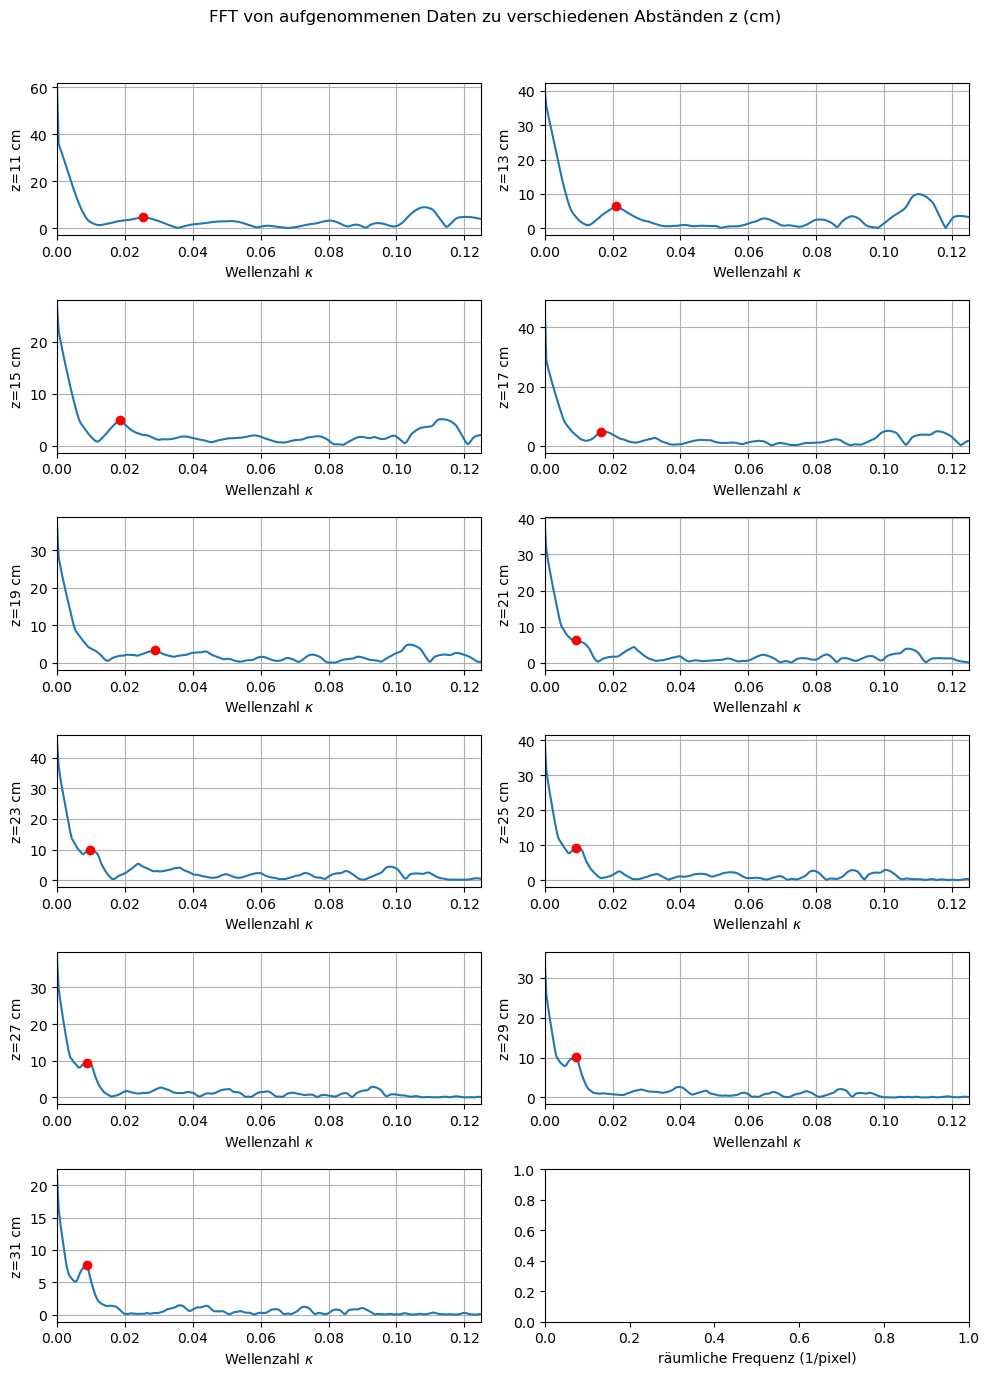

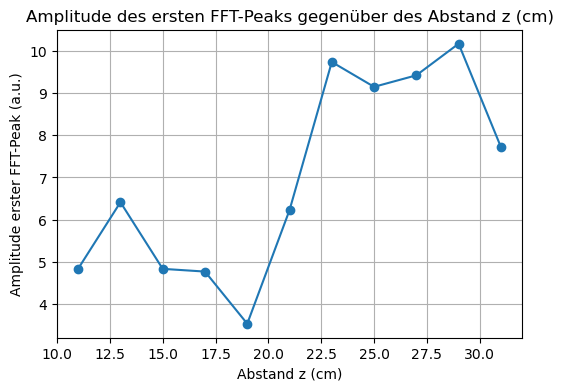

In [20]:
# | fig-cap:
# |     - FFT von jedem Beugungsbild zu einem bestimmten Abstand z und die Amplitude des ersten Maximums
# |     - Amplituden des ersten Maximums in der FFT über den Abstand zwischen Gitter und CCD-Kamera

import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# Positions of the camera on the optical bench (cm) - filenames use these position numbers
_abstand = np.array([47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67])  # positions in cm
# Compute distance from grating to camera: measured position minus grating position at 36 cm -> distances in cm
abstand_cm = _abstand - 36

# Prepare subplots (one per measured position)
Nplots = len(abstand_cm)
fig, axs = plt.subplots(6, 2, figsize=(10, 14))
fig.suptitle("FFT von aufgenommenen Daten zu verschiedenen Abständen z (cm)")

first_order_amplitudes = []
first_order_indices = []
zs = []  # distances in cm (Gitter->Kamera)

for idx, pos in enumerate(_abstand):
    # load data; filenames unchanged and depend on the raw camera position 'pos' (cm)
    df = pd.read_csv(f"./O17 Messdaten/Aufgabe 3/Gitter 1/BeugungGitter{pos}.csv", header=None)
    df.columns = ["pixel", "intensity"]
    intensity = df["intensity"].to_numpy()
    N = len(intensity)

    # FFT and positive half (DC at index 0)
    fy = np.abs(fft(intensity))
    fy_half = fy[: N // 2]
    freqs = fftfreq(N, d=1)[: N // 2]  # unit: 1/pixel

    # peak detection with threshold fallback
    threshold = np.max(fy_half) * 0.08
    peaks, props = find_peaks(fy_half, height=threshold)
    if len(peaks) == 0:
        peaks, props = find_peaks(fy_half)

    peaks = peaks[peaks > 0]
    if len(peaks) == 0:
        peak_idx = np.argmax(fy_half[1:]) + 1
    else:
        peak_idx = peaks.min()

    amp = fy_half[peak_idx]
    first_order_amplitudes.append(amp)
    first_order_indices.append(peak_idx)
    z_cm = pos - 36
    zs.append(z_cm)

    ax = axs.flat[idx] if Nplots > 1 else axs
    ax.plot(freqs, fy_half, label="FFT")
    ax.plot(freqs[peak_idx], fy_half[peak_idx], 'ro', label="1. Peak")
    ax.set_xlim(0, freqs.max())
    ax.set_ylabel(f"z={z_cm} cm")
    ax.set_xlabel("Wellenzahl $\\kappa$")
    ax.set_xlim(0, 0.125)
    ax.grid(True)

plt.xlabel("räumliche Frequenz (1/pixel)")
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Separate plot: amplitude of first peak vs distance in cm
plt.figure(figsize=(6, 4))
plt.plot(zs, first_order_amplitudes, 'o-', linewidth=1.5)
plt.xlabel('Abstand z (cm)')
plt.ylabel('Amplitude erster FFT-Peak (a.u.)')
plt.title('Amplitude des ersten FFT-Peaks gegenüber des Abstand z (cm)')
plt.grid(True)

#print("Gefundene erste Peak-Indizes (positive Hälfte):", first_order_indices)
#print("Abstände z (cm):", zs)
#print("Amplituden (a.u.):", first_order_amplitudes)

## Berechnung der Talbot-Länge

Das Hauptziel der dritten Aufgabe war es die Talbot-Länge der Gitters zu bestimmen, welches der periodische Abstand vom Gitter zur Kamera ist, wo das Gitter sich selbst abbildet. Dieses kann theoretisch mit folgender Formel berechnet werden.
$$t_B = \frac{2g²}{\lambda}$$
Für unsere Werte, die wir bei unserem Experiment benutzt haben ($g=0.125\text{mm}$, $\lambda = 636 \text{nm}$) kommen wir auf einen Talbotwert von $4.914 \text{cm}$ kommen.

Den experimentellen Wert bekommen wir die Periodizität aus dem Plot, der die Amplitude des ersten FFT-Peaks wird als Funktion des Abstands z darstellt, ermitteln. Die Periodizität dieser Amplituden-Oszillation entspricht der Talbot-Länge. Dabei sieht man, dass man keine schöne Oszillation erkennen kann. So wurden Händisch die markierten Werte genommen und eine Periodizität von $8\text{cm}$ bestimmt.


Gefundene Peak-Positionen (z in mm): [13 23 29]
Perioden zwischen Peaks (mm): [10  6]
Ausgewählte Messpunkte (z in mm): [2, 6, 11] -> [13, 21, 31]
Amplituden an diesen Punkten (a.u.): [6.41320149698291, 6.225342387187383, 7.723120344808564]
Experimentelle Talbot-Länge (Mittel): 8.000 cm (Std 2.828)
Theoretische Talbot-Länge (a = 0.125 mm, λ = 636.0 nm): 4.914 cm
Relative Abweichung: 62.8 %


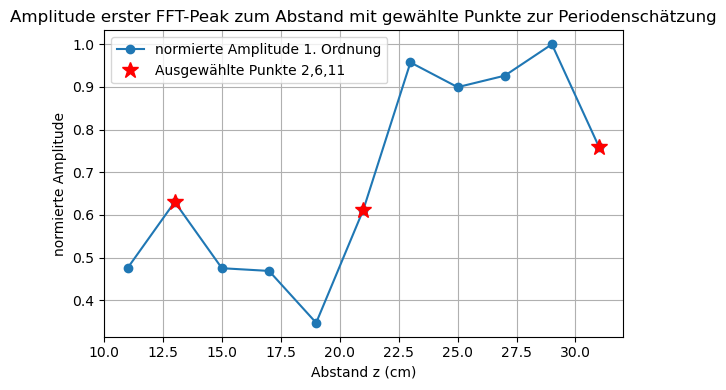

In [ ]:
# | fig-cap: Amplitude des ersten maximas über den Abstand zwischen Kamera und Gitter, mit markierter Periodischen Andeutung und berechneter Periode.
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Benutze die aus der vorherigen Zelle bestimmten Werte: 'zs' und 'first_order_amplitudes'
try:
    zs_arr = np.array(zs)
    amps = np.array(first_order_amplitudes)
except NameError:
    raise NameError("Variable 'zs' oder 'first_order_amplitudes' nicht gefunden. Bitte vorherige Zelle ausführen.")

# Normiere die Amplitude (nur für Plot)
amps_norm = amps / np.max(amps)

# Spezifische Punkte verwenden: Punkt 2, 6 und 11 (vom Nutzer gewünscht). Diese sind 1-basiert.
selected = [2, 6, 11]  # 1-basiert
idxs = [s - 1 for s in selected]
if max(idxs) >= len(zs_arr):
    raise IndexError(f"Ausgewählte Messpunkte {selected} sind nicht alle vorhanden. Vorhandene Messpunkte: {len(zs_arr)}")

z2, z6, z11 = zs_arr[idxs[0]], zs_arr[idxs[1]], zs_arr[idxs[2]]
amp2, amp6, amp11 = amps[idxs[0]], amps[idxs[1]], amps[idxs[2]]

# Alternative Periodenschätzung: Finde die Maxima der Amplituden und berechne deren mittleren Abstand

# Finde Peaks in der normierten Amplitude
peak_idxs, _ = find_peaks(amps_norm, height=0.5)  # Threshold ggf. anpassen
z_peaks = zs_arr[peak_idxs]

if len(z_peaks) < 2:
    raise ValueError("Nicht genügend Peaks gefunden für Periodenschätzung.")

# Berechne die Abstände zwischen den Peaks
periods = np.diff(z_peaks)
zT_exp = periods.mean()
zT_exp_std = periods.std(ddof=1)

# Für die Ausgabe: Zeige die gefundenen Peak-Positionen und Perioden
#print(f"Gefundene Peak-Positionen (z in mm): {z_peaks}")
#print(f"Perioden zwischen Peaks (mm): {periods}")
#periods = np.array([p1, p2, p3])
#zT_exp = periods.mean()
#zT_exp_std = periods.std(ddof=1)

# Theoretische Talbot-Länge (anpassbare Werte)
a_mm = 0.125  # [mm] - passe an (z.B. 0.125 oder 0.25)
lambda_m = 636e-9  # [m] Laserwellenlänge
a_m = a_mm * 1e-3
zT_theo_m = 2 * a_m ** 2 / lambda_m
zT_theo_cm = zT_theo_m * 1e2

# Ausgabe
#print(f"Ausgewählte Messpunkte (z in mm): {selected} -> {[z2, z6, z11]}")
#print(f"Amplituden an diesen Punkten (a.u.): {[amp2, amp6, amp11]}")
#print(f"Periodenschätzungen (mm): p1={p1:.3f}, p2={p2:.3f}, p3={p3:.3f}")
print(f"Experimentelle Talbot-Länge (Mittel): {zT_exp:.3f} cm (Std {zT_exp_std:.3f})")
print(f"Theoretische Talbot-Länge (a = {a_mm} mm, λ = {lambda_m*1e9:.1f} nm): {zT_theo_cm:.3f} cm")
print(f"Relative Abweichung: {(zT_exp - zT_theo_cm)/zT_theo_cm*100:.1f} %")

# Plot: normierte Amplitude und markiere die gewählten Punkte
plt.figure(figsize=(6,4))
plt.plot(zs_arr, amps_norm, 'o-', label='normierte Amplitude 1. Ordnung')
plt.plot([z2, z6, z11], [amps_norm[idxs[0]], amps_norm[idxs[1]], amps_norm[idxs[2]]], 'r*', markersize=12, label='Ausgewählte Punkte 2,6,11')
plt.xlabel('Abstand z (cm)')
plt.ylabel('normierte Amplitude')
plt.title('Amplitude erster FFT-Peak zum Abstand mit gewählte Punkte zur Periodenschätzung')
plt.grid(True)
plt.legend()
plt.tight_layout()


## Fehlerbetrachtung
Da wir einne sehr großen relativen Fehler für die letzte Aufgabe erhalten lohnt es ich nochmal speziell anzuschauen wie man darauf kommen konnte.
Ein möglicher Grund für den sehr großen relativen Fehler (über 60 %) liegt darin, dass unsere Kamera viel Streulicht aufgenommen hat, da der Laser stark gestreut wurde. Dadurch waren im aufgenommenen Abbildungsbild keine klaren Muster erkennbar, was die Messung erheblich erschwert hat. Die Bestimmung der Talbot-Länge erfolgte daher nur grob, indem wir die Abstände zwischen den Messpunkten etwa auf eine halbe theoretische Talbot-Länge gelegt haben. Zudem war die Anzahl der Messpunkte mit nur 11 deutlich zu gering – mit etwa 50 Messpunkten hätte man die Oszillation der Amplitude wesentlich besser auflösen und den Einfluss von Rauschen deutlich reduzieren können. Mehr Datenpunkte wären also notwendig gewesen, um verlässlichere und genauere Ergebnisse zu erhalten.

# Fehlerbetrachtung
Bei unserem Experimentieraufbau, hatte die CCD-Zeilenkamera oft übersteuert, weshalb wir die zwei Polarisationsfilter die gnaze Zeit auf der Einstellung hatte, das die Intensität nur minimal war. Zudem waren unsere Interferenzmuster bei jeder Aufgabe sehr ungenau und haten viel Streulicht. Erst nach etwas ausprobieren, ist aufgefallen, dass eine Schraube kurz nach dem Lase, den Strah streute und somit ins Beugungsmuster, welches mit der Kamera aufgenommen wurde, viel noise rein gebracht hat. Für eine schnelle Lösung haben wir deshalb, mehrere Stücke schwarzes Isolierband genommen und über die erste Blende geklebt, dass das Laserlicht nur noch durch ein kleines Loch kam. So wurden die Messungen, genauer und hatten weniger Streuung. Auch waren die Linsen nicht ganz sauber was zu Messabweichungen führen könnte. Weitere Messunsicherheiten können durch eine leicht falsche Justierung des Laserstrahls kommen, wobei wir uns aber sehr sicher sind, dass der Strahl gut zentriet war auf der Kamera. Zudem kommen klassische Messfehler, wie ablesen der Positionen, der optischen Instrumente auf der Bank oder die Messunsicherheit von der CCD-Zeilenkamera.